#   Bước 1. Chuẩn bị thư viện

In [3]:
# Chuẩn bị thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.inspection import permutation_importance

import warnings

warnings.filterwarnings('ignore')

# Bước 2. Tiền xử lý dữ liệu

## 2.1 Tải tập dữ liệu

In [4]:
# --- 2.1 Tải tập dữ liệu ---
df = pd.read_csv('student_depression_dataset.csv')
df.columns = df.columns.str.strip()


## 2.2 Xử lý dữ liệu đầu vào

In [ ]:
# Map tay , đưa dữ liệu về kiểu số
df['Sleep_Score'] = df['Sleep Duration'].map({'Less than 5 hours': 1, '5-6 hours': 2, '7-8 hours': 3, 'More than 8 hours': 4}).fillna(2)
df['Diet_Score'] = df['Dietary Habits'].map({'Unhealthy': 1, 'Moderate': 2, 'Healthy': 3}).fillna(2)
for col in ['Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
le = LabelEncoder()
for col in ['Gender', 'Degree', 'Profession', 'City']:
    df[col] = le.fit_transform(df[col].astype(str))

# Chuẩn bị X, y
X = df.drop(columns=['id', 'Depression', 'Sleep Duration', 'Dietary Habits'])
y = df['Depression']

# Xử lý lỗi '?'
X = X.replace('?', np.nan)
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Feature Engineering
X['Total_Pressure'] = X['Academic Pressure'] + X['Work Pressure']

# Impute
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


## 2.3 Chia tập dữ liệu

In [ ]:
# Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Biến lưu kết quả tổng hợp
baseline_results = {}

print(f"Kích thước tập Train: {X_train.shape}")

Kích thước tập Train: (22320, 17)


## 2.4 Xây dựng hàm đánh giá cho toàn bộ mô hình

In [ ]:
# Hàm đánh giá mô hình
def run_step(model, name):
    print(f"\n{'='*50}")
    print(f"▶ ĐANG HUẤN LUYỆN: {name}")
    print(f"{'='*50}")

    # Huấn luyện
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Tính toán chỉ số
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Lưu kết quả (Nếu biến global tồn tại)
    baseline_results[name] = acc

    print(f"✅ Accuracy: {acc:.4f}")
    print(f"✅ F1-Score: {f1:.4f}")
    print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

    # Vẽ Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự đoán')
    plt.show()

    # TRẢ VỀ MÔ HÌNH ---
    return model

# Bước 3. Xây dựng mô hình



##  3.1 Thuật toán Decision Tree

Đang tìm tham số tối ưu cho Decision Tree (sẽ mất một chút thời gian)...
Tham số tốt nhất tìm được: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Decision Tree Accuracy: 0.8208
Best Decision Tree F1 Score: 0.8201

▶ ĐANG HUẤN LUYỆN: Decision Tree
✅ Accuracy: 0.8208
✅ F1-Score: 0.8495

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.76      0.78      2313
           1       0.84      0.86      0.85      3268

    accuracy                           0.82      5581
   macro avg       0.82      0.81      0.81      5581
weighted avg       0.82      0.82      0.82      5581



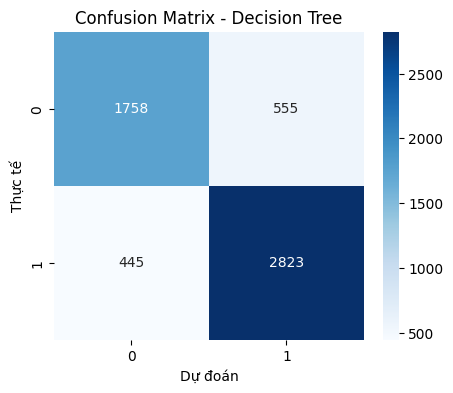

In [ ]:
# 1. Định nghĩa các tham số
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'class_weight': [None, 'balanced']
}

# 2. Thiết lập tìm kiếm (Grid Search)
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,               # Chia 5 phần để kiểm tra
    scoring='f1_weighted',
    n_jobs=-1
)

print("Đang tìm tham số tối ưu cho Decision Tree (sẽ mất một chút thời gian)...")
grid_search.fit(X_train, y_train)

# 3. Lấy ra mô hình tốt nhất
best_dt = grid_search.best_estimator_
print("Tham số tốt nhất tìm được:", grid_search.best_params_)

# 4. Dự đoán bằng mô hình tốt nhất này
y_pred = best_dt.predict(X_test)

# 5. Tính kết quả
acc_dt = accuracy_score(y_test, y_pred)
f1_dt = f1_score(y_test, y_pred, average='weighted')

print(f"Best Decision Tree Accuracy: {acc_dt:.4f}")
print(f"Best Decision Tree F1 Score: {f1_dt:.4f}")

# 6. Gán lại vào biến dt để chạy run_step
dt = run_step(best_dt, "Decision Tree")

## 3.2 Thuật toán LightGBM


Đang tối ưu hóa LightGBM (Chờ xíu nhé)...
Tham số tốt nhất: {'class_weight': None, 'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 35, 'subsample': 0.6}

▶ ĐANG HUẤN LUYỆN: LightGBM
✅ Accuracy: 0.8436
✅ F1-Score: 0.8685

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81      2313
           1       0.86      0.88      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581



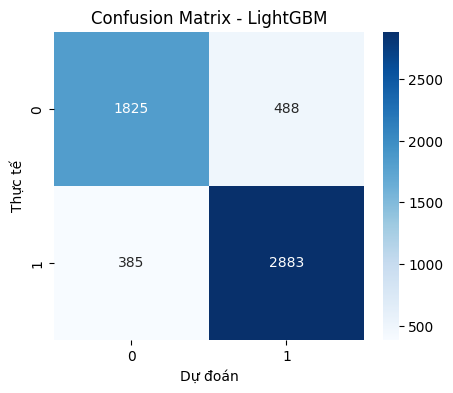

In [ ]:
# 1. Định nghĩa không gian tìm kiếm
param_dist = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': randint(20, 50),
    'max_depth': [5, 10, 15, -1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'class_weight': [None, 'balanced']
}

# 2. Thiết lập tìm kiếm ngẫu nhiên
lgbm_search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=param_dist,
    n_iter=20,              # Thử 20 tổ hợp ngẫu nhiên
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    random_state=42
)

print("Đang tối ưu hóa LightGBM (Chờ xíu nhé)...")
lgbm_search.fit(X_train, y_train)

# 3. Lấy ra mô hình tốt nhất
best_lgbm = lgbm_search.best_estimator_
print(f"Tham số tốt nhất: {lgbm_search.best_params_}")

# 4. Dự đoán bằng mô hình tối ưu nhất
y_pred = best_lgbm.predict(X_test)

# 5. Tính toán kết quả
acc_lgbm = accuracy_score(y_test, y_pred)
f1_lgbm = f1_score(y_test, y_pred, average='weighted')

# 6. Lưu vào quy trình
lgbm = run_step(best_lgbm, "LightGBM")


## 3.3 Thuật toán XGBoost


▶ ĐANG HUẤN LUYỆN: XGBoost
✅ Accuracy: 0.8427
✅ F1-Score: 0.8676

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.81      2313
           1       0.86      0.88      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.84      5581
weighted avg       0.84      0.84      0.84      5581



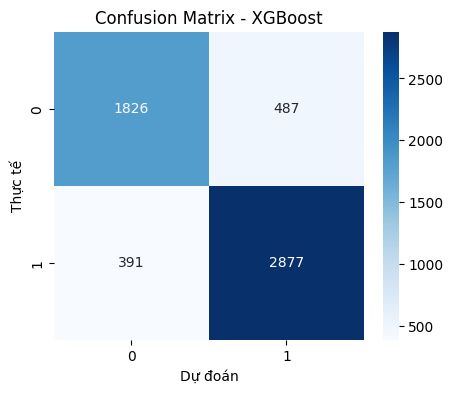

In [ ]:
# 1. Khởi tạo mô hình XGBoost với các tham số cụ thể
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# 2. Đưa vào quy trình chạy (run_step)
xgb = run_step(xgb, "XGBoost")

# 3. Dự đoán và tính toán kết quả sau khi đã train xong
y_pred = xgb.predict(X_test)

# Tính toán các chỉ số
acc_xgb = accuracy_score(y_test, y_pred)
f1_xgb = f1_score(y_test, y_pred, average='weighted')



## 3.4 Thuật toán Stacking Classifier



▶ ĐANG HUẤN LUYỆN: Stacking Classifier
✅ Accuracy: 0.8425
✅ F1-Score: 0.8676

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.81      2313
           1       0.85      0.88      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.84      5581
weighted avg       0.84      0.84      0.84      5581



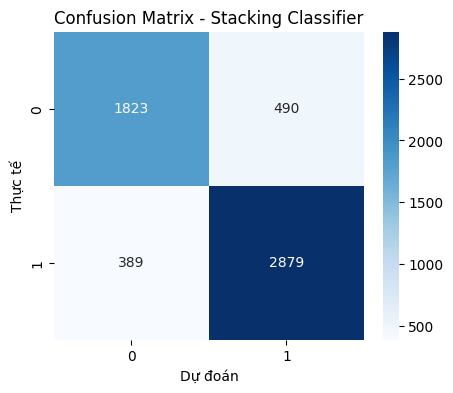

In [ ]:
# 1. Định nghĩa các Base Estimators và Stacking Model
estimators = [
    ('dt', dt),
    ('lgbm', lgbm),
    ('xgb', xgb)
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

# 2. Huấn luyện mô hình (Hàm run_step trả về mô hình đã train)
stacking = run_step(stacking, "Stacking Classifier")

# Dự đoán trên tập X_test
y_pred_stacking = stacking.predict(X_test)

# Tính Accuracy
acc_stacking = accuracy_score(y_test, y_pred_stacking)

# Tính F1-Score
f1_stacking = f1_score(y_test, y_pred_stacking, average='weighted')

# Bước 4. So sánh tổng hợp 4 thuật toán

## 4.1 Tổng hợp kết quả 4 thuật toán

In [ ]:
# 1. Gom dữ liệu của 4 thuật toán
results_base = pd.DataFrame({
    'Model': ['Decision Tree', 'XGBoost', 'LightGBM', 'Stacking Classifier'],
    'Accuracy': [acc_dt, acc_xgb, acc_lgbm, acc_stacking],
    'F1-Score': [f1_dt, f1_xgb, f1_lgbm, f1_stacking]
})

print("\n--- Tổng hợp kết quả Baseline ---")
print(results_base)

# 2. Chuyển đổi dữ liệu (Melt) để vẽ 2 cột song song
results_melted = results_base.melt(id_vars="Model", var_name="Metric", value_name="Score")



--- Tổng hợp kết quả Baseline ---
                 Model  Accuracy  F1-Score
0        Decision Tree  0.820821  0.820121
1              XGBoost  0.842681  0.842152
2             LightGBM  0.843576  0.843009
3  Stacking Classifier  0.842501  0.841942


## 4.2 Vẽ biểu đồ hiển thị kết quả so sánh

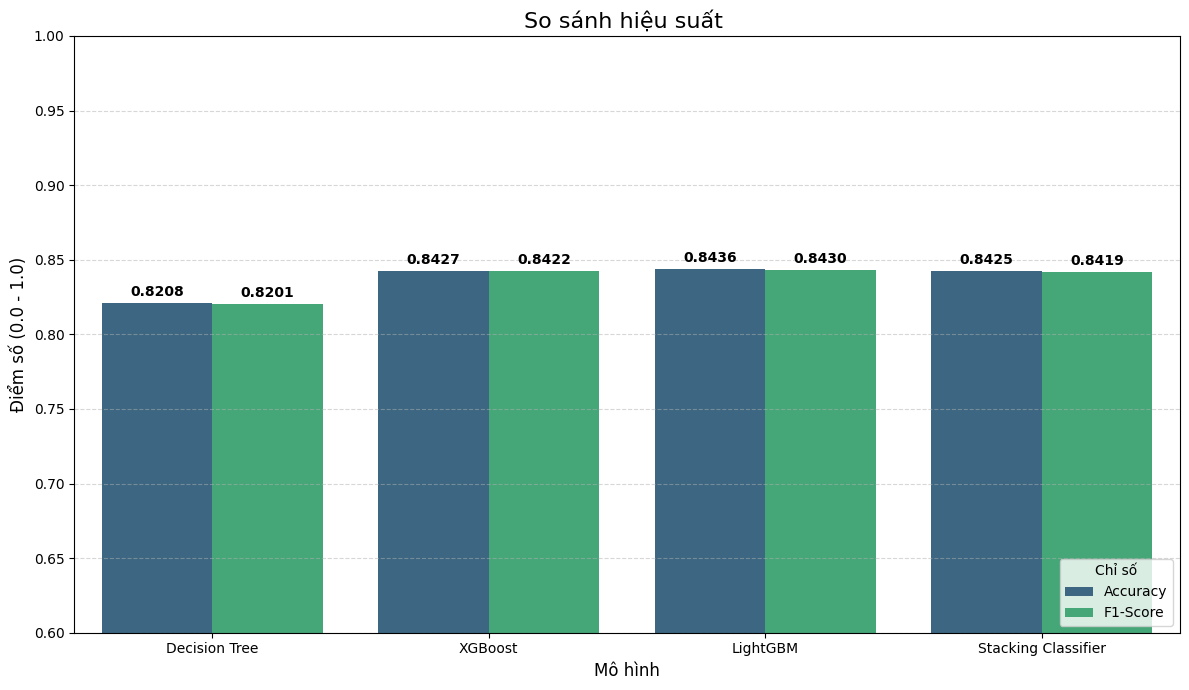

In [ ]:
# 3. Vẽ biểu đồ
plt.figure(figsize=(12, 7))

# hue='Metric' giúp tách Accuracy và F1 thành 2 màu riêng biệt
ax = sns.barplot(x='Model', y='Score', hue='Metric', data=results_melted, palette='viridis')

# 4. Trang trí
plt.ylim(0.6, 1.0)
plt.title('So sánh hiệu suất ', fontsize=16)
plt.ylabel('Điểm số (0.0 - 1.0)', fontsize=12)
plt.xlabel('Mô hình', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='lower right', title='Chỉ số')

# 5. Hiển thị số điểm cụ thể trên đầu cột
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Bước 5. Tổng hợp thuộc tính ảnh hưởng đến kết quả


## 5.1 Tính toán và xử lý mức độ ảnh hưởng

In [ ]:
# 1. Tính toán Permutation Importance
print("Đang tính toán Permutation Importance (có thể mất chút thời gian)...")

# Tính toán mức độ ảnh hưởng
perm_importance = permutation_importance(stacking, X_test, y_test, n_repeats=10, random_state=42)


Đang tính toán Permutation Importance (có thể mất chút thời gian)...


## 5.2 Vẽ biểu đồ biểu diễn mức độ ảnh hưởng

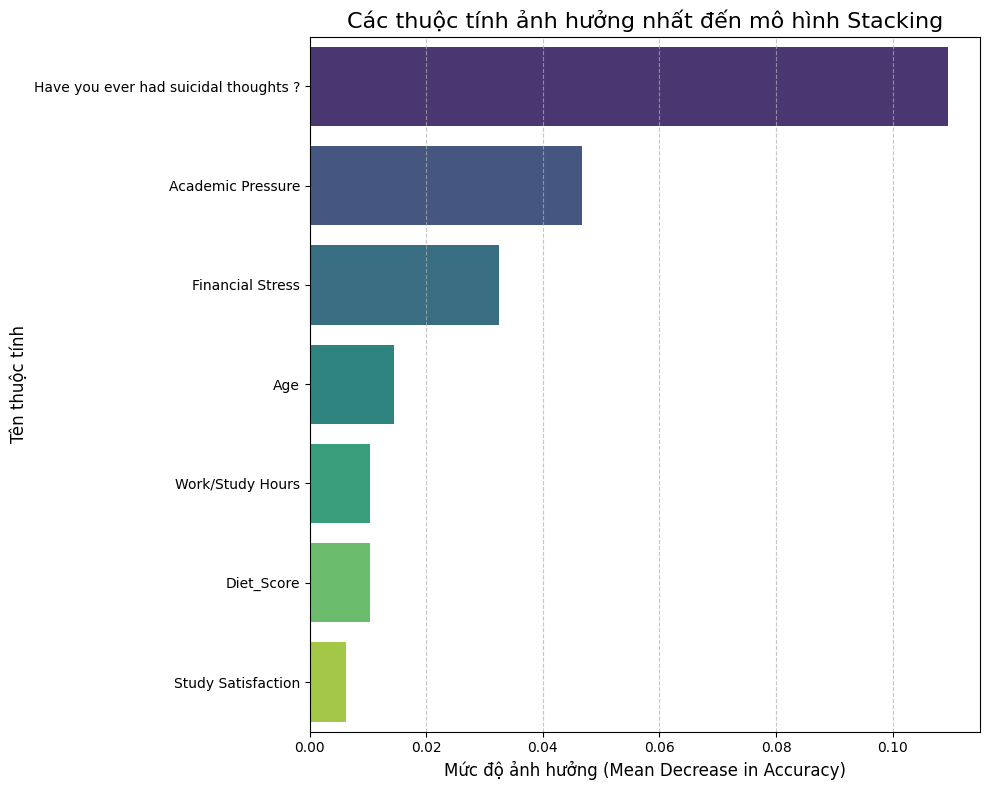

In [ ]:
# 2. Xử lý tên cột
if hasattr(X_test, 'columns'):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# 3. Tạo DataFrame kết quả
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean
})

# Sắp xếp giảm dần
df_importance = df_importance.sort_values(by='Importance', ascending=False)

# 4. Vẽ biểu đồ
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(7), palette='viridis')

plt.title('Các thuộc tính ảnh hưởng nhất đến mô hình Stacking', fontsize=16)
plt.xlabel('Mức độ ảnh hưởng (Mean Decrease in Accuracy)', fontsize=12)
plt.ylabel('Tên thuộc tính', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()